In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [12]:
def extract_precise_grid_hough(binary_path):
    binary = cv2.imread(binary_path, cv2.IMREAD_GRAYSCALE)
    
    circles = cv2.HoughCircles(
        binary, 
        cv2.HOUGH_GRADIENT, 
        dp=1,           # Inverse ratio of accumulator resolution
        minDist=20,     # Minimum distance between circle centers (IMPORTANT!)
        param1=50,      # Upper threshold for edge detection
        param2=20,      # Accumulator threshold for center detection
        minRadius=8,    # Minimum circle radius
        maxRadius=50    # Maximum circle radius
    )
    
    coords = []
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        coords = [(x, y) for x, y in circles[:, :2]]
        print(f"Found {len(coords)} circles with Hough")
    else:
        print("No circles found with Hough!")
    
    return coords

def extract_precise_grid(binary_path):
    binary = cv2.imread(binary_path, cv2.IMREAD_GRAYSCALE)
    
    template_size = 30  # Bigger template
    template = np.zeros((template_size, template_size), dtype=np.uint8)
    cv2.circle(template, (template_size//2, template_size//2), 8, 255, -1)  # Solid circle
    cv2.circle(template, (template_size//2, template_size//2), 12, 0, 3)    # Black ring around it
    
    result = cv2.matchTemplate(binary, template, cv2.TM_CCOEFF_NORMED)
    
    # MUCH higher threshold
    threshold = 0.8  # Increased from 0.7
    locations = np.where(result >= threshold)
    
    # Remove duplicate detections (Non-Maximum Suppression)
    coords_raw = list(zip(locations[1], locations[0]))
    
    # Filter out coordinates that are too close to each other
    coords = []
    min_distance = 25  # Minimum pixels between pin centers
    
    for x, y in coords_raw:
        # Check if this coord is far enough from existing ones
        too_close = False
        for existing_x, existing_y in coords:
            distance = np.sqrt((x - existing_x)**2 + (y - existing_y)**2)
            if distance < min_distance:
                too_close = True
                break
        
        if not too_close:
            coords.append((x, y))
    
    print(f"Found {len(coords)} pins after filtering")
    return coords

def extract_aligned_pins(image_path, coords, crop_size=32):
    """Extract pins with better preprocessing"""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # CLAHE for better contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    
    pins = []
    for i, (cx, cy) in enumerate(coords):
        half = crop_size // 2
        
        # Better boundary checking
        if (cy-half >= 0 and cx-half >= 0 and cy+half < enhanced.shape[0] and cx+half < enhanced.shape[1]):
            crop = enhanced[cy-half:cy+half, cx-half:cx+half]
            
            # Normalize each pin individually
            crop = cv2.normalize(crop, None, 0, 255, cv2.NORM_MINMAX)
            crop = cv2.GaussianBlur(crop, (3,3), 0)
            
            pins.append((crop, i, cx, cy))
    
    return pins

Mapped 1871 pins.


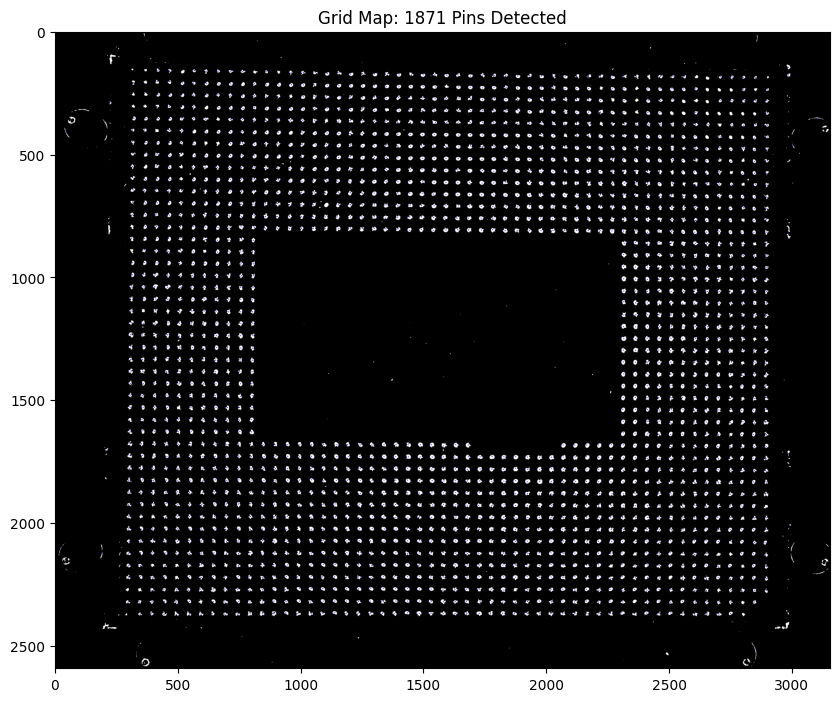

Dataset generated at datasets/socket_pins
Mapped 1886 pins.


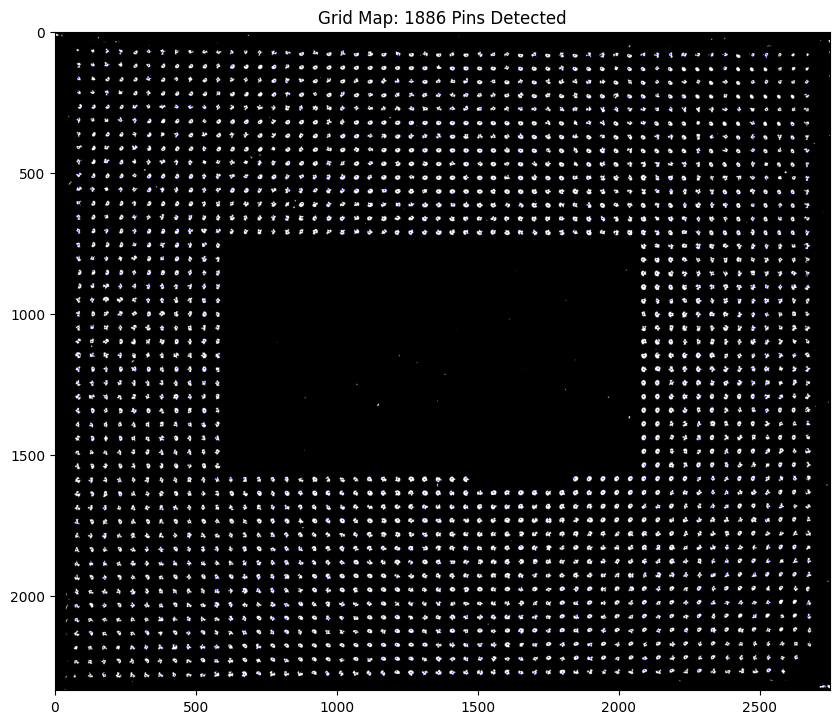

Dataset generated at datasets/socket_pins
Mapped 1277 pins.


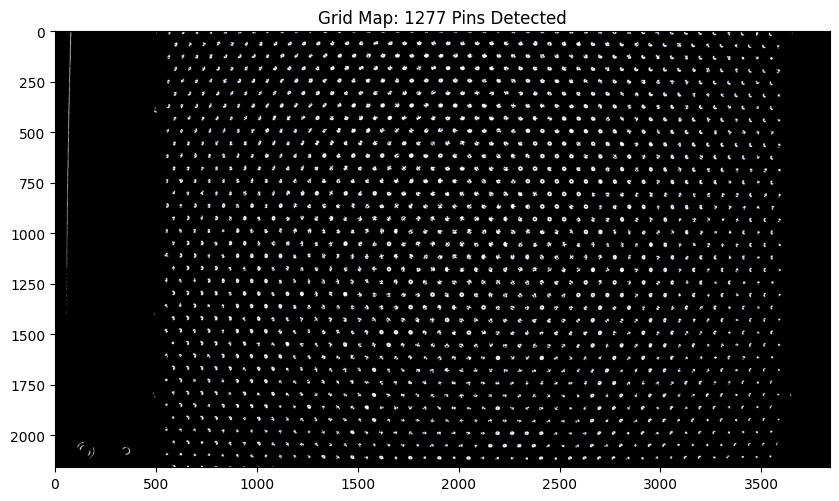

Dataset generated at datasets/socket_pins


In [21]:
def filter_good_pins(pins, variance_threshold=100):
    """Remove blurry/bad quality pins"""
    good_pins = []
    
    for crop, idx, x, y in pins:
        # Check if pin is in focus (Laplacian variance)
        variance = cv2.Laplacian(crop, cv2.CV_64F).var()
        
        if variance > variance_threshold:
            good_pins.append((crop, idx, x, y))
    
    print(f"Filtered {len(pins)} -> {len(good_pins)} quality pins")
    return good_pins

def visualize_pin_quality(pins):
    """Check your extracted pins before training"""
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    for i, (crop, idx, x, y) in enumerate(pins[:32]):
        row, col = i // 8, i % 8
        axes[row, col].imshow(crop, cmap='gray')
        axes[row, col].set_title(f"{idx}")
        axes[row, col].axis('off')
    plt.show()

Processing DSC00297.JPG...
Found 8 circles with Hough
Filtered 8 -> 8 quality pins


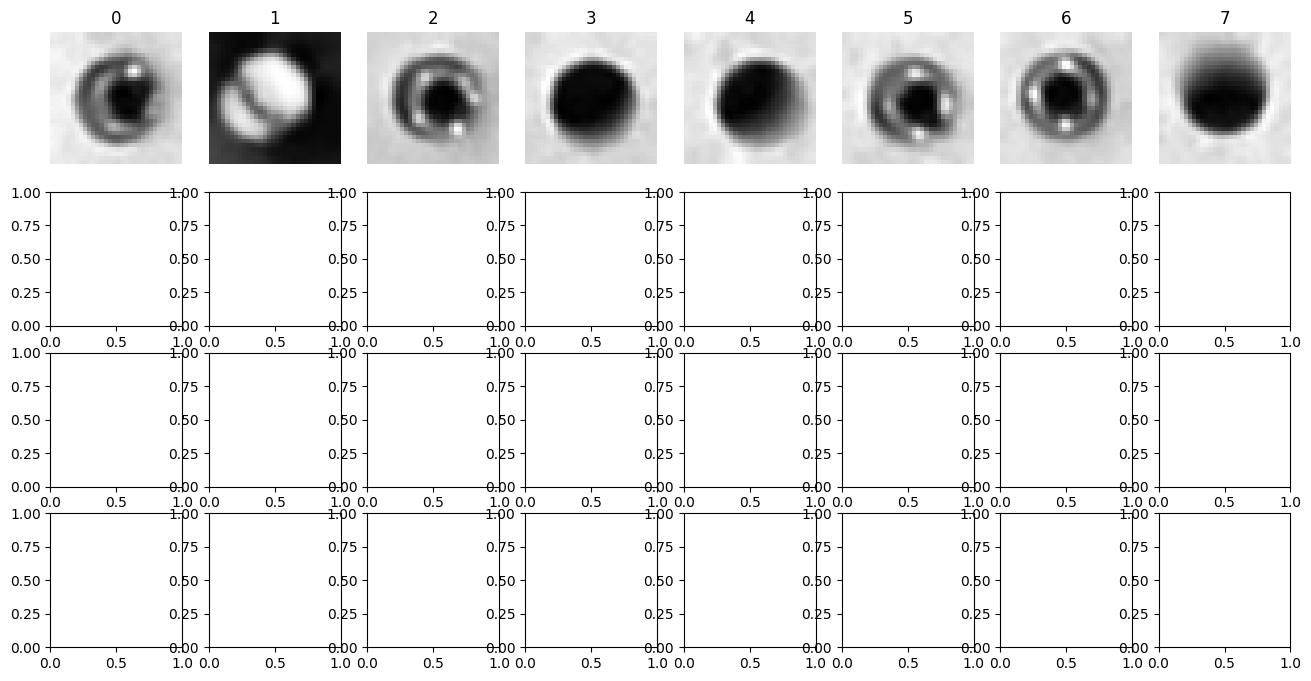

Dataset generated at datasets/socket_pins
Processing DSC00298.JPG...
Found 6 circles with Hough
Filtered 6 -> 6 quality pins


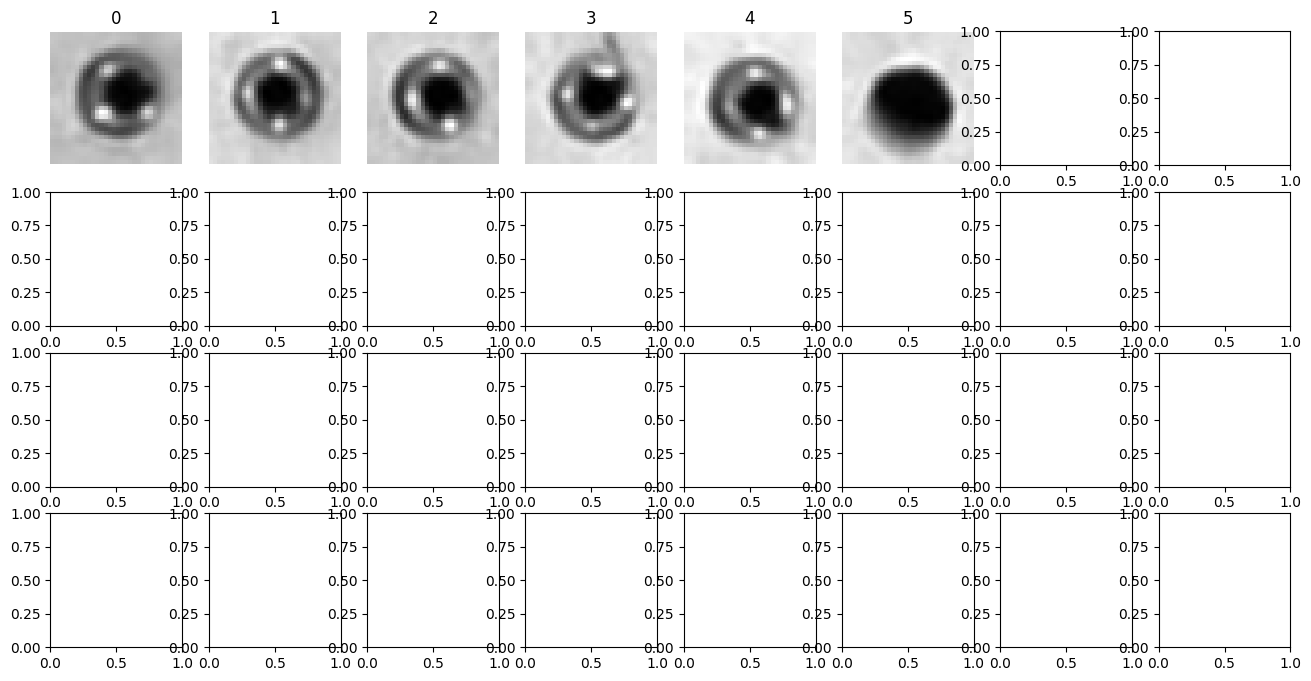

Dataset generated at datasets/socket_pins
Processing DSC00374.JPG...
Found 121 circles with Hough
Filtered 121 -> 119 quality pins


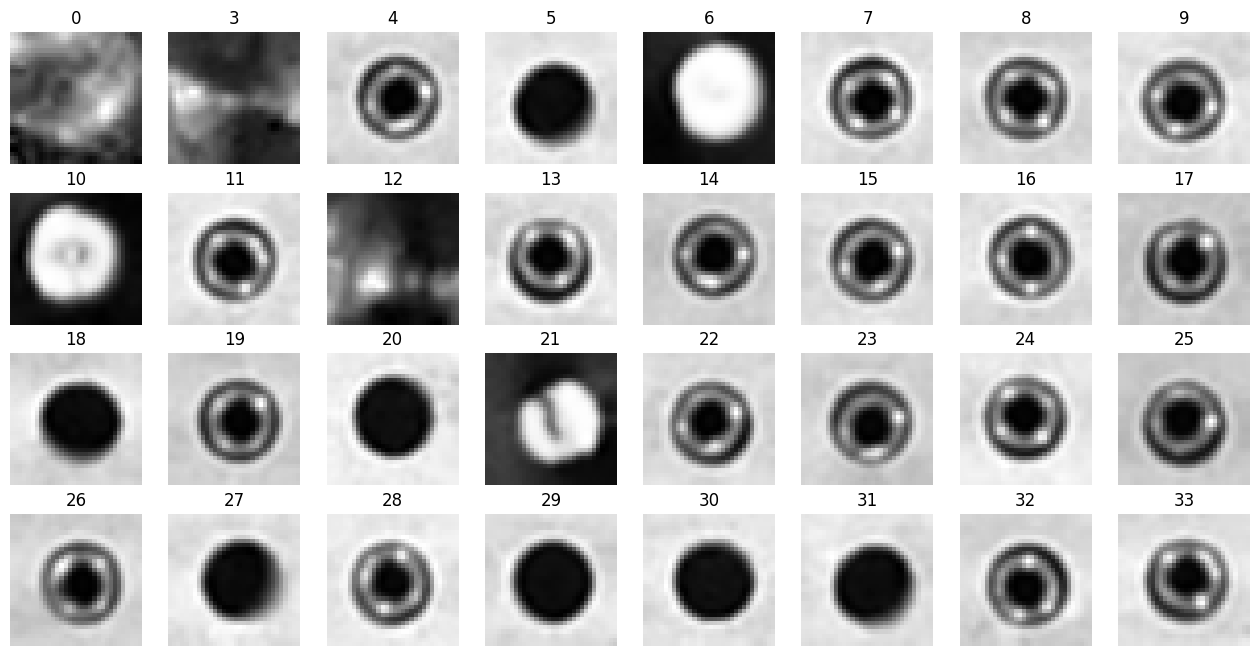

Dataset generated at datasets/socket_pins
Processing WIN_20251209_16_13_21_Pro.jpg...
Found 9 circles with Hough
Filtered 9 -> 8 quality pins


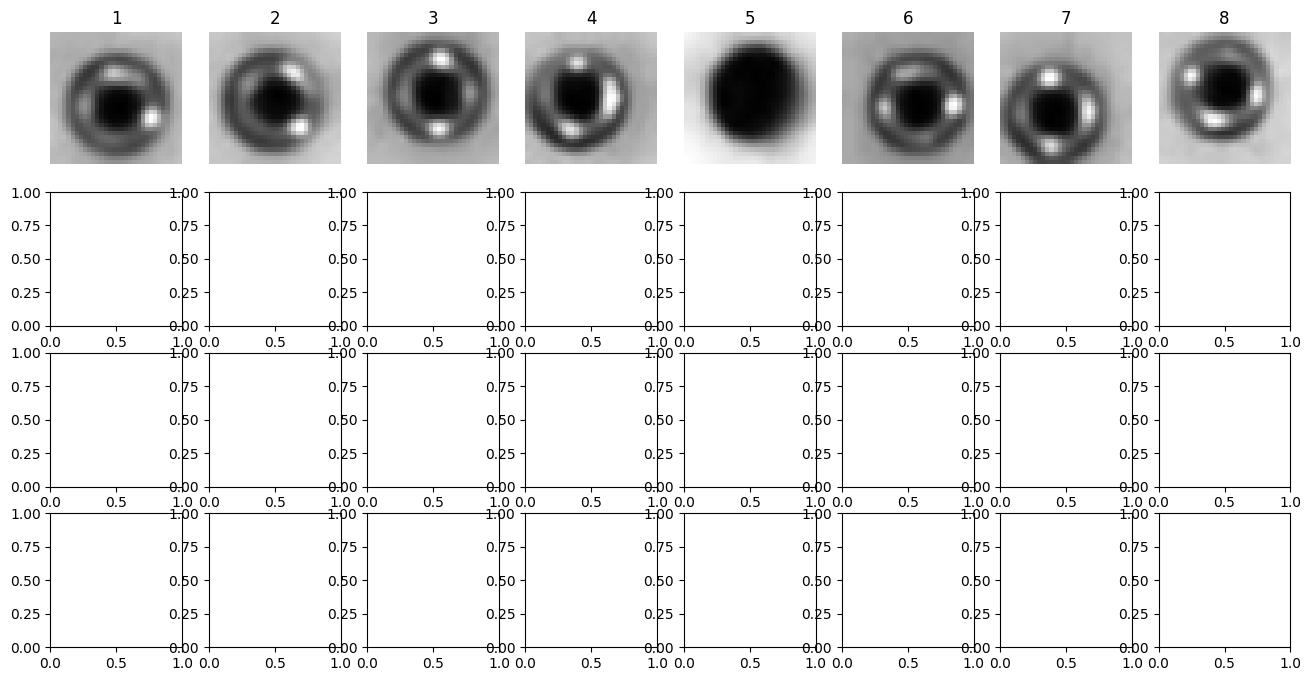

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_52_19_Pro.jpg...
Found 137 circles with Hough
Filtered 137 -> 133 quality pins


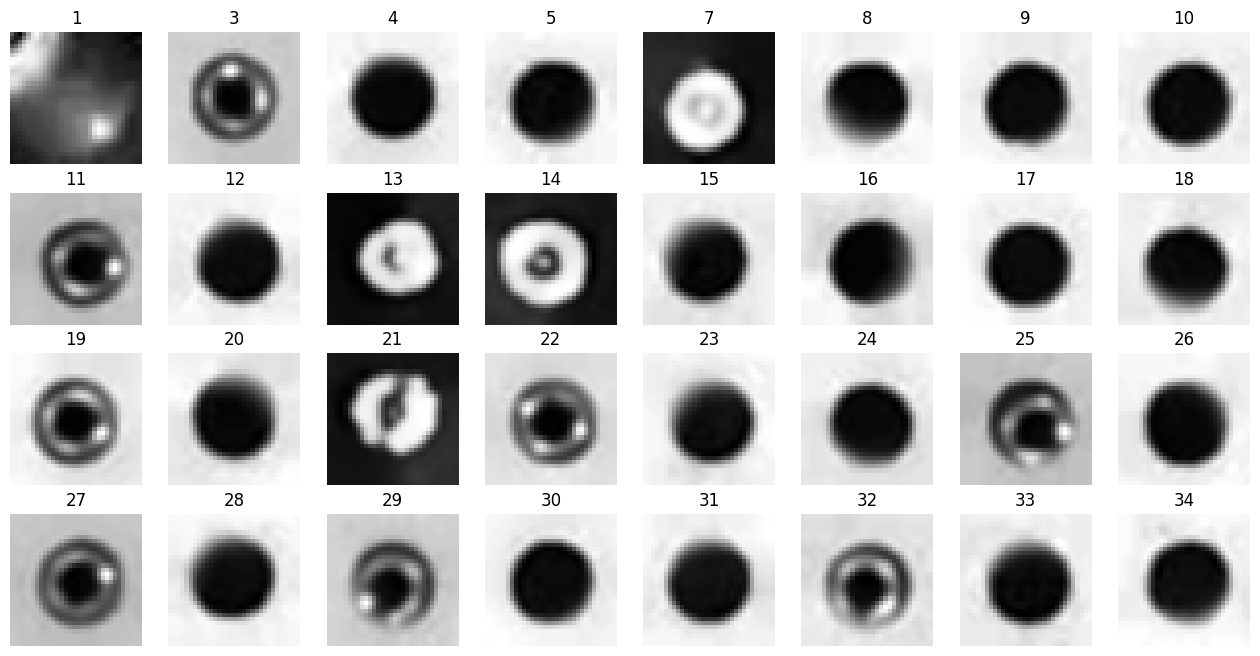

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_54_05_Pro.jpg...
Found 144 circles with Hough
Filtered 144 -> 139 quality pins


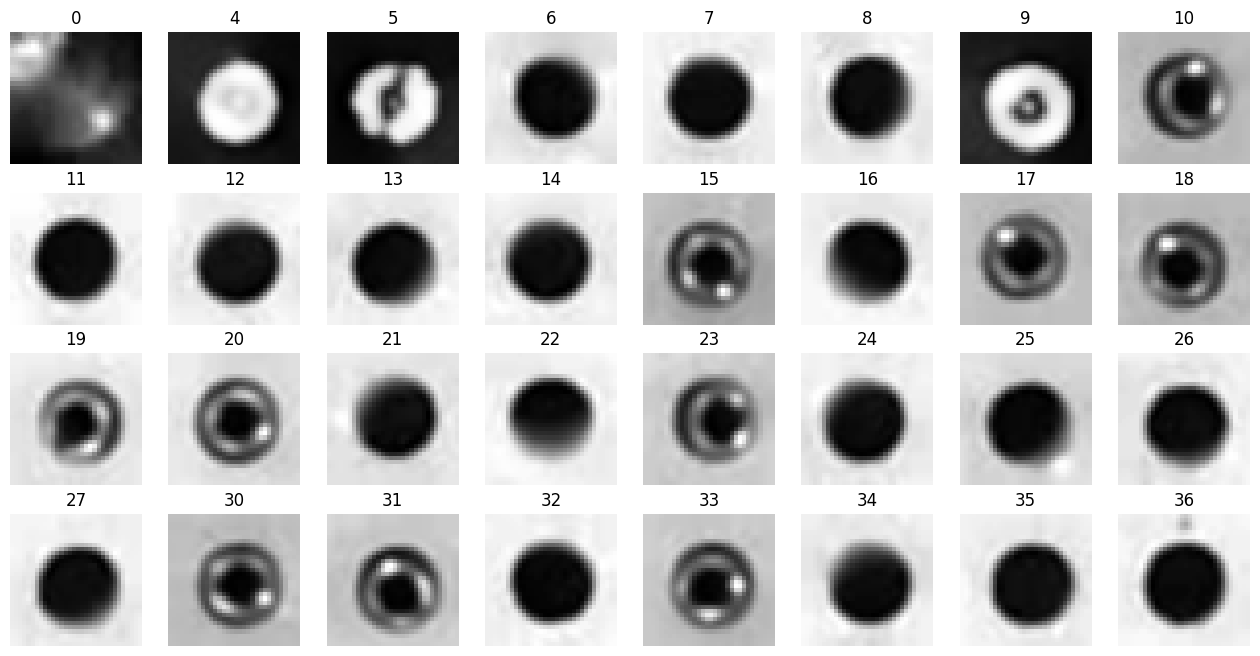

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_54_18_Pro.jpg...
Found 82 circles with Hough
Filtered 82 -> 80 quality pins


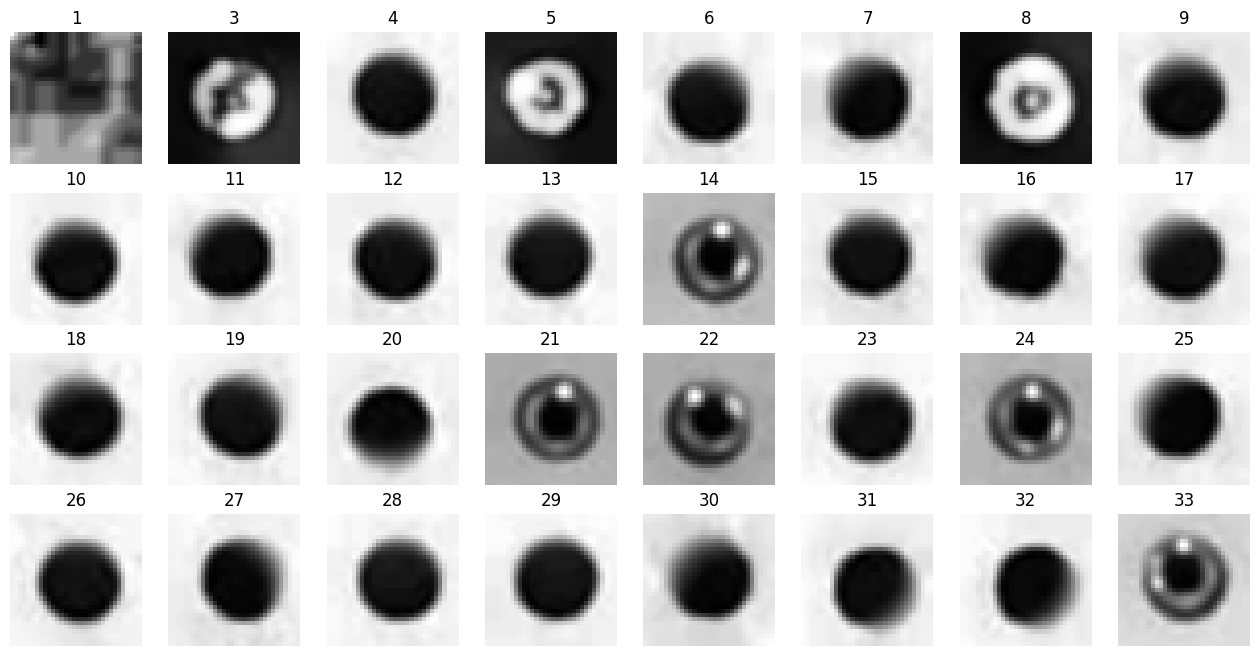

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_54_33_Pro.jpg...
Found 91 circles with Hough
Filtered 91 -> 89 quality pins


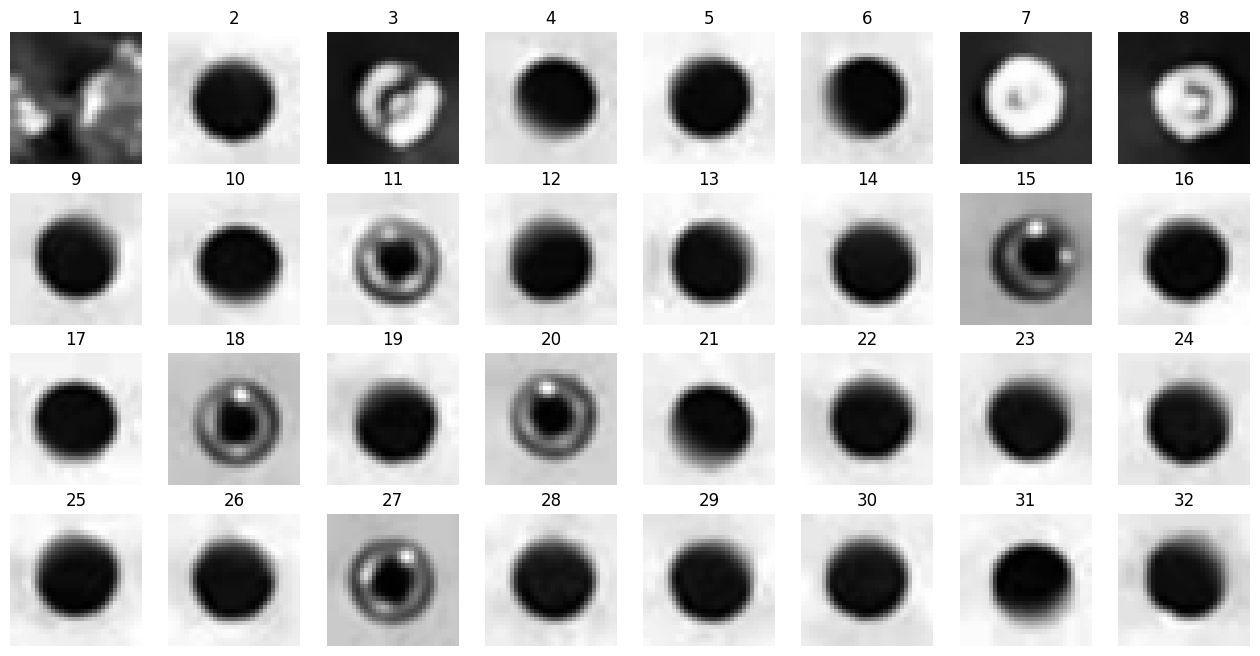

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_55_03_Pro.jpg...
Found 67 circles with Hough
Filtered 67 -> 63 quality pins


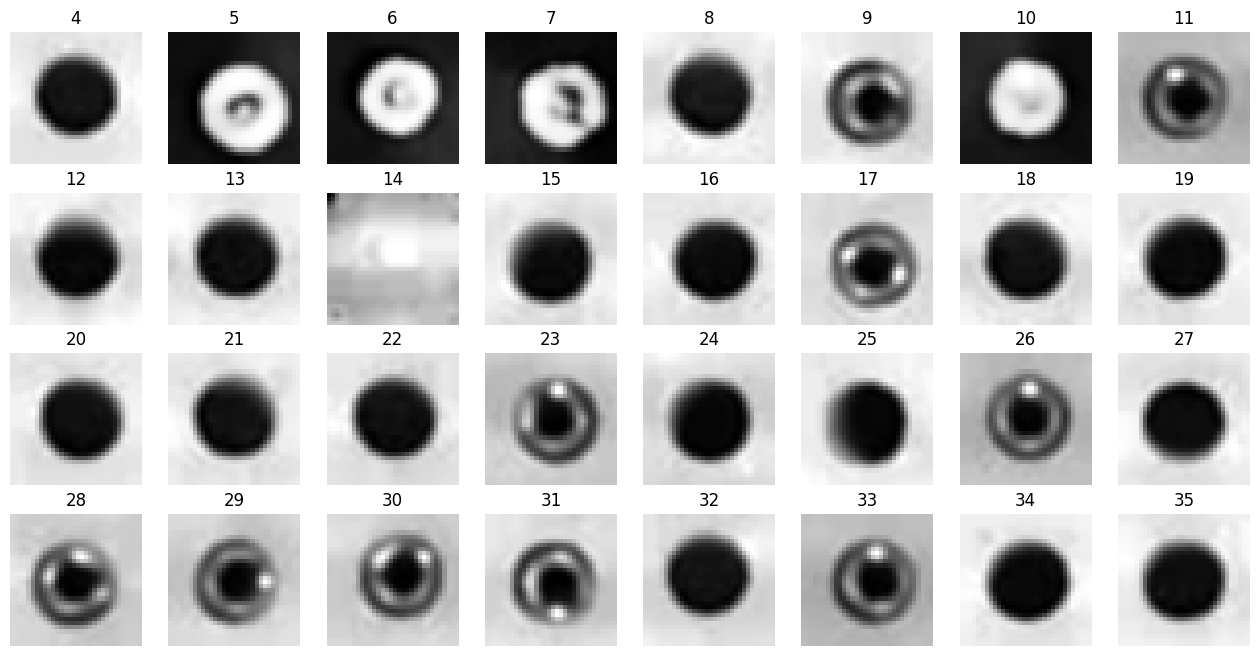

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_55_56_Pro.jpg...
Found 86 circles with Hough
Filtered 86 -> 84 quality pins


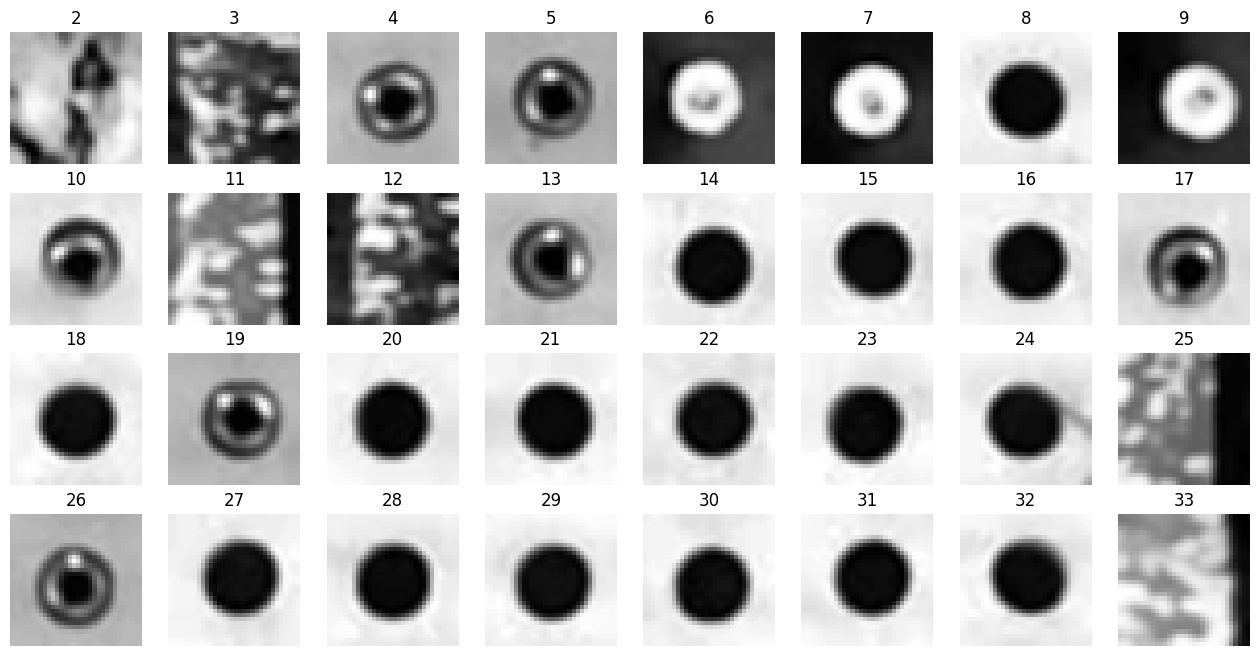

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_56_00_Pro.jpg...
Found 58 circles with Hough
Filtered 58 -> 56 quality pins


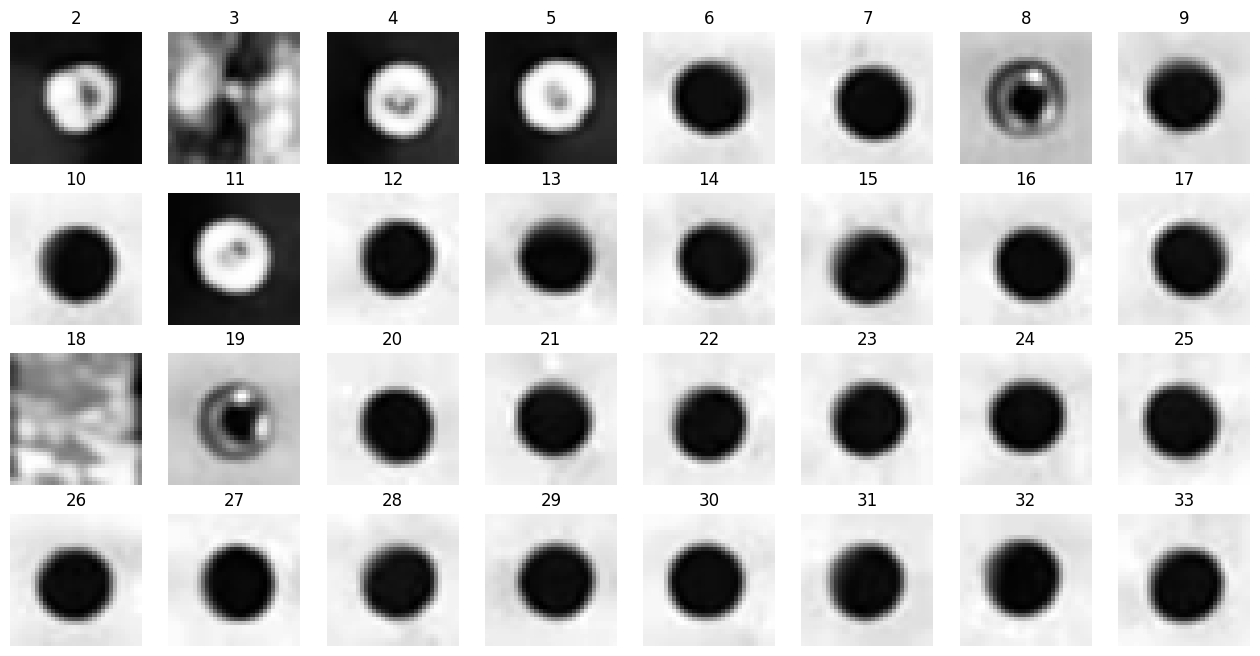

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_56_26_Pro.jpg...
Found 89 circles with Hough
Filtered 89 -> 87 quality pins


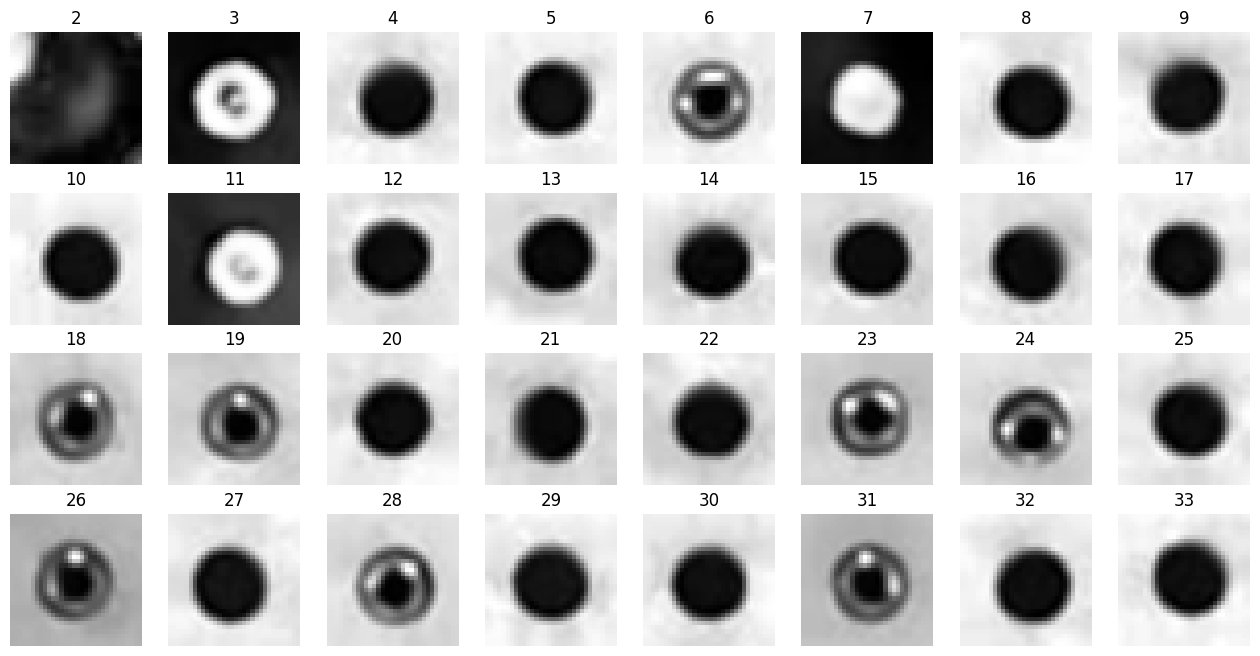

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_56_55_Pro.jpg...
Found 84 circles with Hough
Filtered 84 -> 81 quality pins


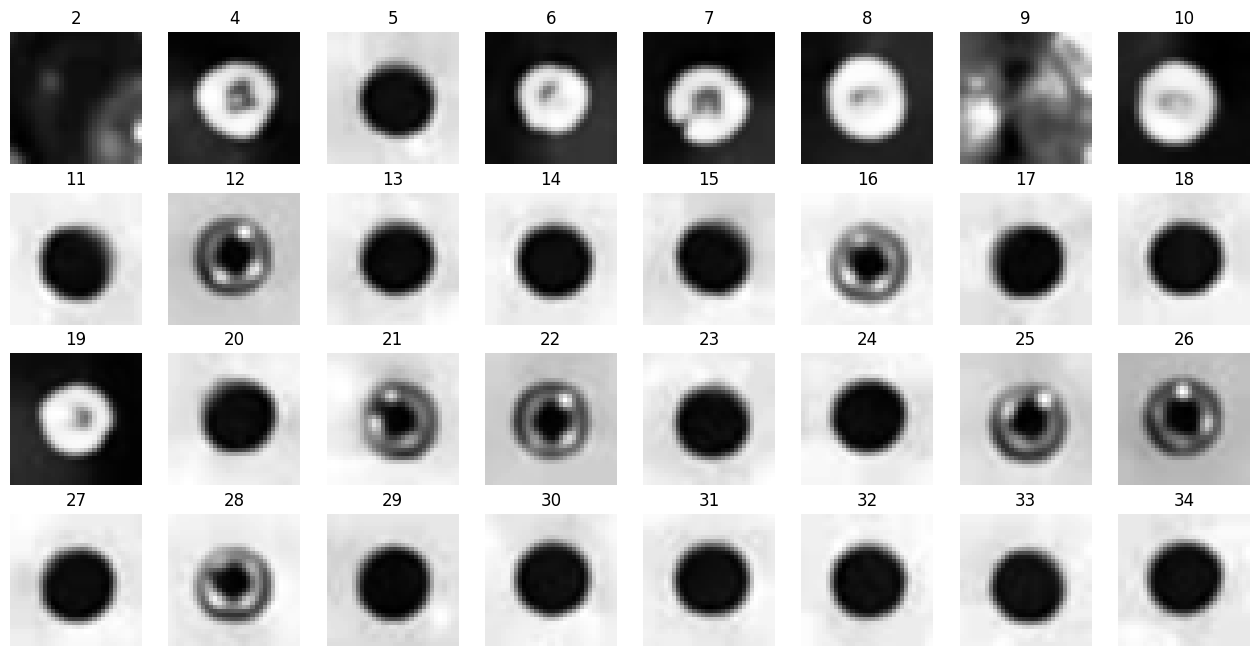

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_57_07_Pro.jpg...
Found 108 circles with Hough
Filtered 107 -> 106 quality pins


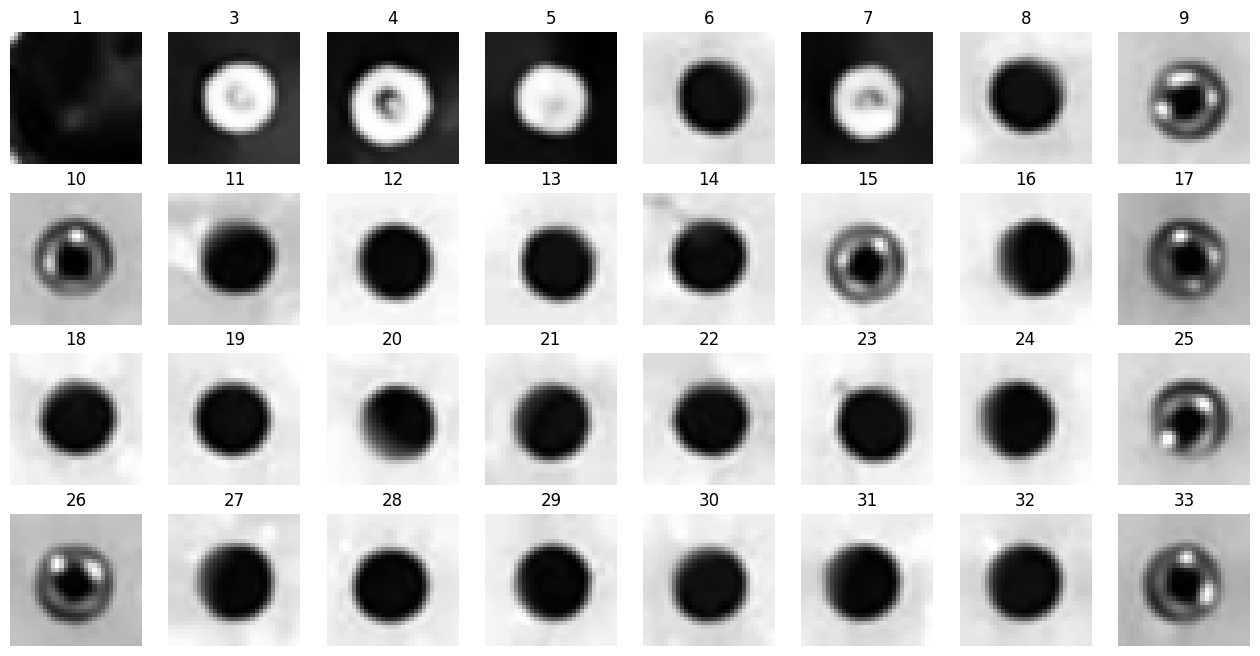

Dataset generated at datasets/socket_pins
Processing WIN_20251217_13_57_17_Pro.jpg...
Found 60 circles with Hough
Filtered 60 -> 57 quality pins


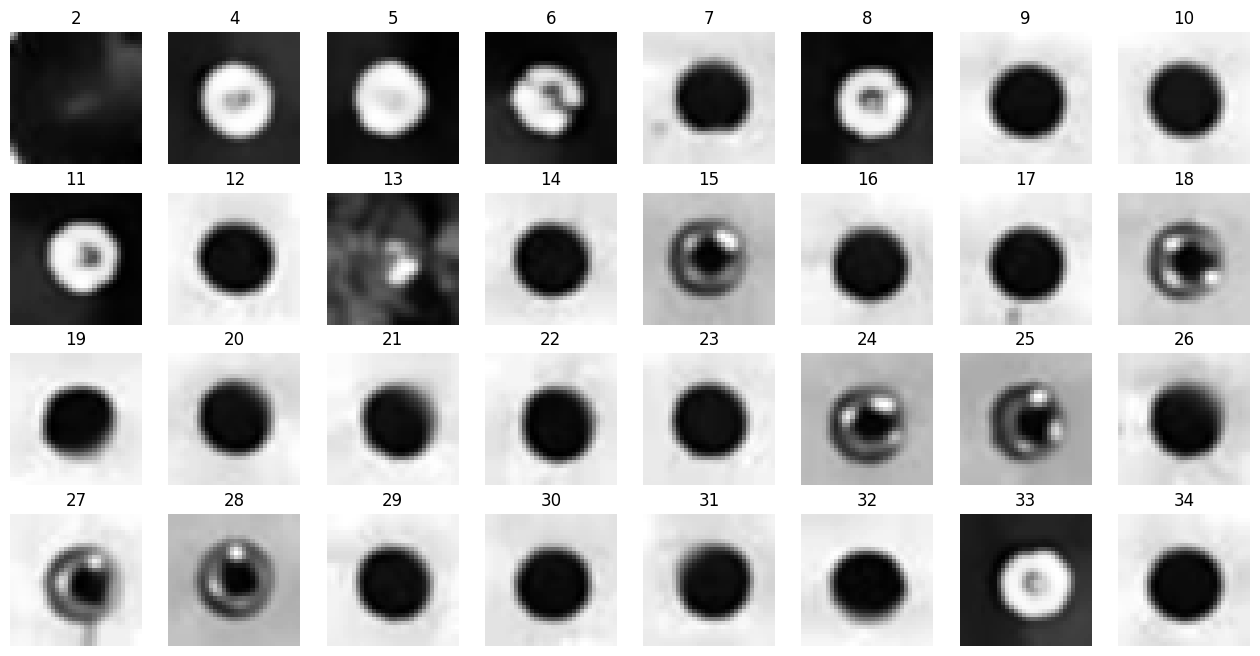

Dataset generated at datasets/socket_pins
Processing WIN_20251217_14_04_04_Pro.jpg...
Found 90 circles with Hough
Filtered 90 -> 90 quality pins


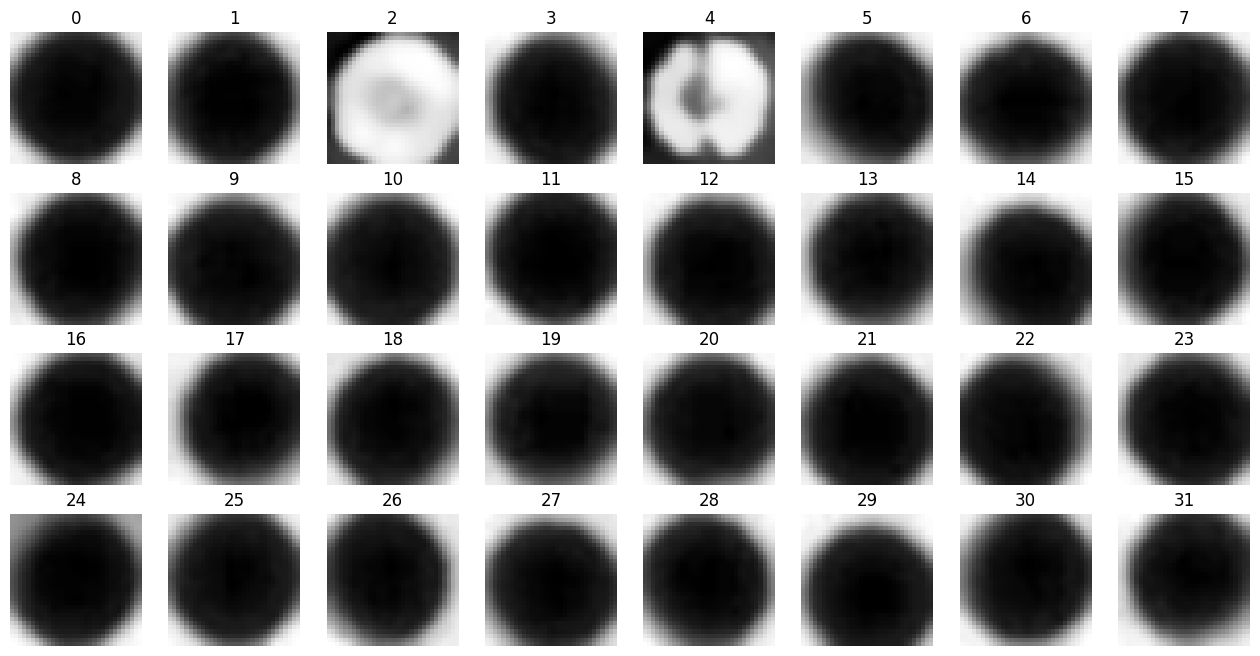

Dataset generated at datasets/socket_pins


In [14]:
# Use the coordinates we found in the previous step
# coords = [(x1,y1), (x2,y2), ...] 

def create_anomalib_dataset(image_path, coords, output_dir="datasets/socket_pins"):
    img = cv2.imread(image_path)
    
    # Create folders
    train_dir = os.path.join(output_dir, "train/good")
    test_dir = os.path.join(output_dir, "test/good")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    
    # Crop settings
    crop_size = 32  # 32x32 is standard for small features like pins
    half = crop_size // 2
    
    for i, (cx, cy) in enumerate(coords):
        # Boundary check
        if cy-half < 0 or cx-half < 0: continue
        
        crop = img[cy-half:cy+half, cx-half:cx+half]
        
        # Save 80% to Train, 20% to Test
        if i % 5 == 0:
            cv2.imwrite(f"{test_dir}/pin_{i}.png", crop)
        else:
            cv2.imwrite(f"{train_dir}/pin_{i}.png", crop)
            
    print(f"Dataset generated at {output_dir}")

# Main processing loop
for img in os.listdir("./data/socket/"):
    print(f"Processing {img}...")
    
    # Get coordinates from binary image
    binary_path = f"output/adaptive_{img}"
    coords = extract_precise_grid_hough(binary_path)
    
    # Extract pins from original image
    original_path = f"./data/socket/{img}"
    pins = extract_aligned_pins(original_path, coords)
    
    # Filter and visualize
    pins = filter_good_pins(pins)
    visualize_pin_quality(pins)
    
    # Create dataset
    create_anomalib_dataset(original_path, coords)